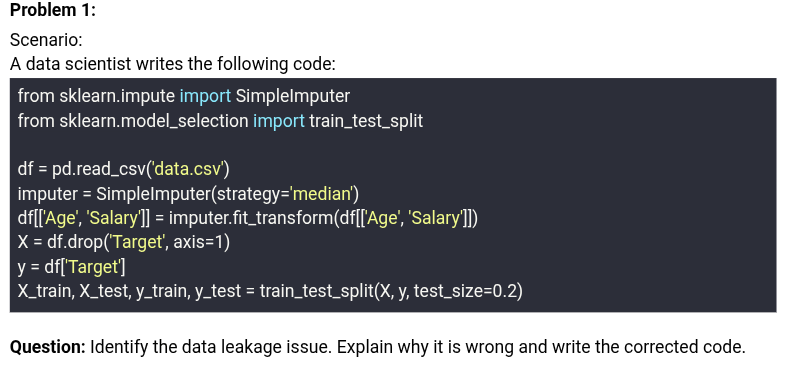

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

df = pd.read_csv('data.csv') 
imputer = SimpleImputer(strategy='median')
X = df.drop('Target', axis=1)
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train[['Age', 'Salary']] = imputer.fit_transform(X_train[['Age', 'Salary']])
X_test[['Age', 'Salary']] = imputer.transform(X_test[['Age', 'Salary']])

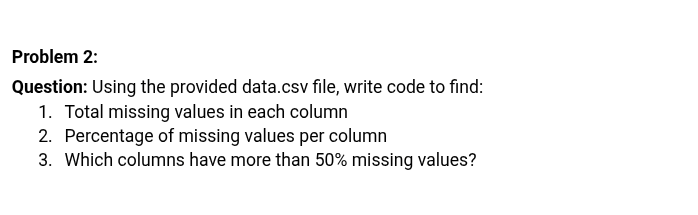

In [ ]:
# missing data calculation for each colulmn
df.isnull().sum()

Age                       180
Income                    150
Salary                      0
Rating                     80
Annual_Income             120
Customer_Support_Calls     80
House_Price               100
Square_Feet                 0
Temperature                50
City                       50
Product_Type                0
Location                    0
Diagnosis                 220
Cabin                     680
Embarked                    2
Gender                      0
Target                      0
Price_Target                0
dtype: int64

In [ ]:
# percentage of missing data each column
(df.isnull().sum() / len(df)) * 100

Age                       18.0
Income                    15.0
Salary                     0.0
Rating                     8.0
Annual_Income             12.0
Customer_Support_Calls     8.0
House_Price               10.0
Square_Feet                0.0
Temperature                5.0
City                       5.0
Product_Type               0.0
Location                   0.0
Diagnosis                 22.0
Cabin                     68.0
Embarked                   0.2
Gender                     0.0
Target                     0.0
Price_Target               0.0
dtype: float64

In [7]:
data = (df.isnull().sum() / len(df)) * 100
data

Age                       18.0
Income                    15.0
Salary                     0.0
Rating                     8.0
Annual_Income             12.0
Customer_Support_Calls     8.0
House_Price               10.0
Square_Feet                0.0
Temperature                5.0
City                       5.0
Product_Type               0.0
Location                   0.0
Diagnosis                 22.0
Cabin                     68.0
Embarked                   0.2
Gender                     0.0
Target                     0.0
Price_Target               0.0
dtype: float64

In [16]:
col = data.index[(data > 50)]
print(col)

Index(['Cabin'], dtype='object')


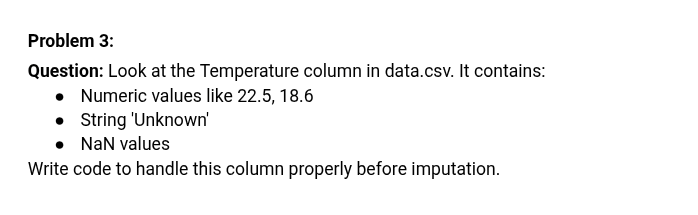

In [17]:
df['Temperature'].isnull().sum()

np.int64(50)

In [18]:
df['Temperature']

0         15.1
1         28.3
2         22.0
3         22.7
4          NaN
        ...   
995       17.0
996       17.0
997       24.7
998    Unknown
999       14.1
Name: Temperature, Length: 1000, dtype: object

In [21]:
temp_nan = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Unknown')
df['Temperature'] = temp_nan.fit_transform(df[['Temperature']]).ravel()

In [27]:
df['Temperature'].isnull().sum()
df['Temperature'].sample(10)

613       24.4
125       24.2
663       23.7
399    Unknown
618       17.4
48     Unknown
526       28.2
179       14.1
136       17.5
767    Unknown
Name: Temperature, dtype: object

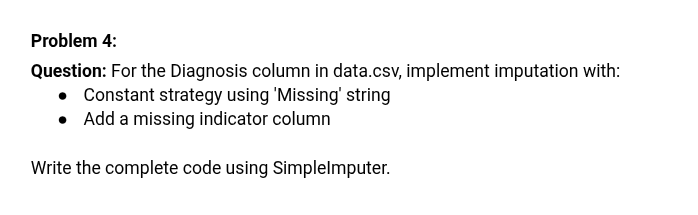

In [28]:
df['Diagnosis'].sample(10)

637      NaN
698    Type1
889    Type2
33       NaN
841    Type3
927    Type2
522      NaN
348    Type3
213    Type3
902      NaN
Name: Diagnosis, dtype: object

In [29]:
df['Diagnosis'].isnull().sum()

np.int64(220)

In [33]:
imputer = SimpleImputer(missing_values=np.nan, strategy='constant', add_indicator=True, fill_value='Missing')

df[['Diagnosis','diagnosis_indicator']] = imputer.fit_transform(df[['Diagnosis']])

In [35]:
df['Diagnosis'].isnull().sum()

np.int64(0)

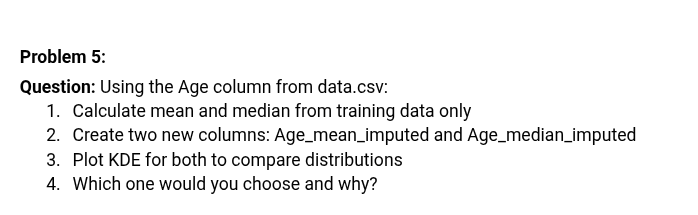

In [41]:
mn = X_train['Age'].mean()
md = X_train['Age'].median()
print(f'mean: {mn} , median: {md}')

mean: 34.52375 , median: 34.0


In [42]:
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X_train['Age_mean_imputed'] = imputer.fit_transform(X_train[['Age']]).ravel()

In [43]:
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
X_train['Age_median_imputed'] = imputer.fit_transform(X_train[['Age']]).ravel()

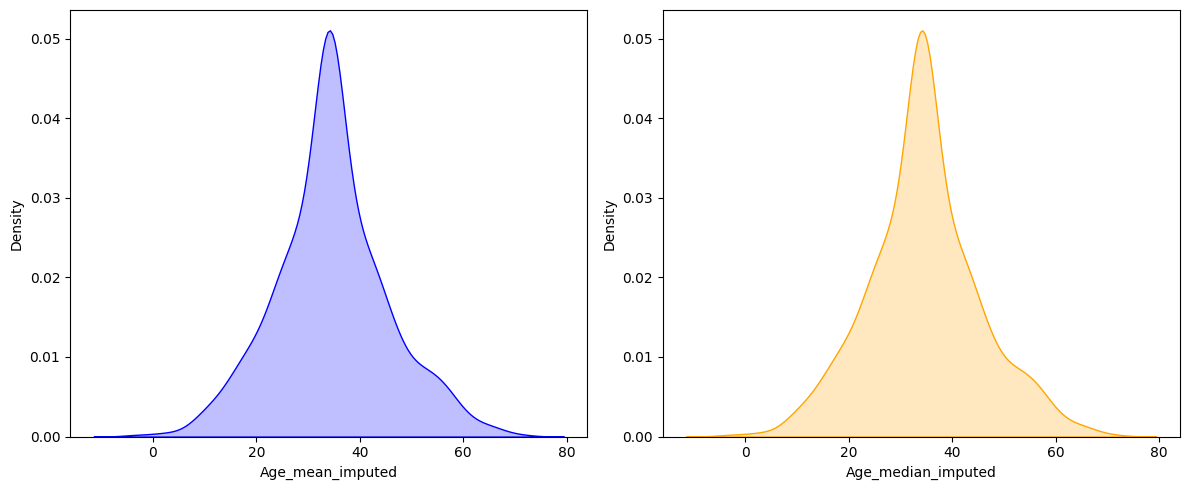

In [50]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(data=X_train, x='Age_mean_imputed', ax=axes[0], fill=True, color='blue')
sns.kdeplot(data=X_train, x='Age_median_imputed', ax =axes[1], fill=True, color='orange')
plt.tight_layout()
plt.show()

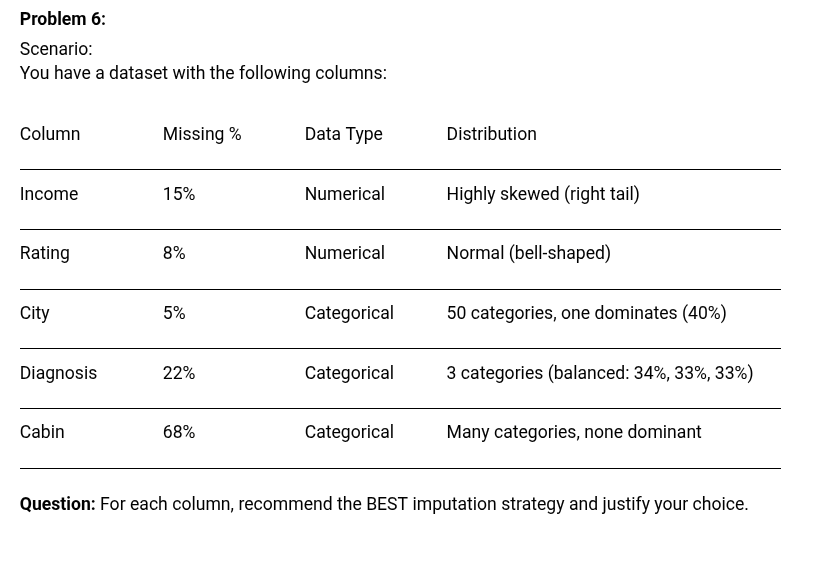